In [1]:
%matplotlib inline

#from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.utils import resample
import seaborn as sns
import matplotlib.pylab as plt

In [2]:
from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)
df = iris.frame
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


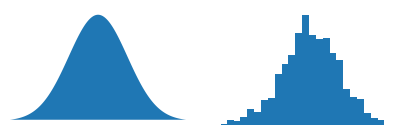

In [3]:
# The Figures explains the difference between Population and Sample
np.random.seed(seed=1)
x = np.linspace(-3, 3, 300)
xsample = stats.norm.rvs(size=1000)

fig, axes = plt.subplots(ncols=2, figsize=(5, 1.5))

ax = axes[0]
ax.fill(x, stats.norm.pdf(x))
ax.set_axis_off()
ax.set_xlim(-3, 3)

ax = axes[1]
ax.hist(xsample, bins=30)
ax.set_axis_off()
ax.set_xlim(-3, 3)
ax.set_position
# plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0, hspace=0)

plt.show()

In [4]:
# sample_data  of size 100 rows that are randomly sleected from pd.DataFrame
sample_data = df.sample(100)
sample_data.shape

(100, 5)

In [5]:
simple_sample = df.sample(15, random_state=42)
simple_sample.shape
simple_sample.head(15)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
73,6.1,2.8,4.7,1.2,1
18,5.7,3.8,1.7,0.3,0
118,7.7,2.6,6.9,2.3,2
78,6.0,2.9,4.5,1.5,1
76,6.8,2.8,4.8,1.4,1
31,5.4,3.4,1.5,0.4,0
64,5.6,2.9,3.6,1.3,1
141,6.9,3.1,5.1,2.3,2
68,6.2,2.2,4.5,1.5,1
82,5.8,2.7,3.9,1.2,1


In [ ]:
#Stratified random sampling is used to the Iris dataset to ensure that each species is 
#represented proportionally (or equally) in your sample.

In [6]:
# the DataFrame is divided into groups by target (species: 0, 1, 2) and 5 rows are selected from each group
stratified_sample = (
    df.groupby(df['target'], group_keys=False)
      .sample(n=5, random_state=42)
)
print(stratified_sample)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
13                 4.3               3.0                1.1               0.1   
39                 5.1               3.4                1.5               0.2   
30                 4.8               3.1                1.6               0.2   
45                 4.8               3.0                1.4               0.3   
17                 5.1               3.5                1.4               0.3   
79                 5.7               2.6                3.5               1.0   
88                 5.6               3.0                4.1               1.3   
52                 6.9               3.1                4.9               1.5   
96                 5.7               2.9                4.2               1.3   
95                 5.7               3.0                4.2               1.2   
101                5.8               2.7                5.1               1.9   
149                5.9      

In [7]:
# Suppose we only select the first 25 rows of each species instead of randomly
# By taking only the first 25 rows, we ignore the last 25 rows of each species.
biased_sample = pd.concat([
    df[df['target']==0].iloc[:25],
    df[df['target']==1].iloc[:25],
    df[df['target']==2].iloc[:25]
])
biased_sample.head(15)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


In [ ]:
# Sampling Mean vs Population Mean

In [20]:
# Population mean of sepal length
population_mean = df['sepal length (cm)'].mean()
print("Population mean (μ):", population_mean)

# Random sample of 10 rows
sample = df.sample(n=10, random_state=42)

# Sample mean of sepal length
sample_mean = sample['sepal length (cm)'].mean()
print("Sample mean (x̄):", sample_mean)

Population mean (μ): 5.843333333333334
Sample mean (x̄): 6.220000000000001


In [9]:
# Selection Bias Example
# Biased sample: only type 1 target (setosa)
biased_sample = df[df['target'] == 0]

# Population mean
population_mean = df['sepal length (cm)'].mean()

# Biased sample mean
biased_sample_mean = biased_sample['sepal length (cm)'].mean()

print("Population mean (μ):", population_mean)
print("Biased sample mean (x̄):", biased_sample_mean)


Population mean (μ): 5.843333333333334
Biased sample mean (x̄): 5.006


In [10]:
#Using the Iris dataset, we will sample flowers and compute the mean of one feature to study the sampling distribution.

sepal_length = df["sepal length (cm)"]

population = pd.DataFrame({
    "sepal_length_mean": sepal_length,
    "type": "Population"
})
sample_mean_05 = pd.DataFrame({
    "sepal_length_mean": [sepal_length.sample(5).mean() for _ in range(100)],
    "type": "Mean of 5"
})
sample_mean_20 = pd.DataFrame({
    "sepal_length_mean": [sepal_length.sample(20).mean() for _ in range(100)],
    "type": "Mean of 20"
})

sample_mean_25 = pd.DataFrame({
    "sepal_length_mean": [sepal_length.sample(25).mean() for _ in range(100)],
    "type": "Mean of 25"
})

results = pd.concat([population, sample_mean_05, sample_mean_20, sample_mean_25])
print(results.head())
print(sample_mean_05.shape)

   sepal_length_mean        type
0                5.1  Population
1                4.9  Population
2                4.7  Population
3                4.6  Population
4                5.0  Population
(100, 2)


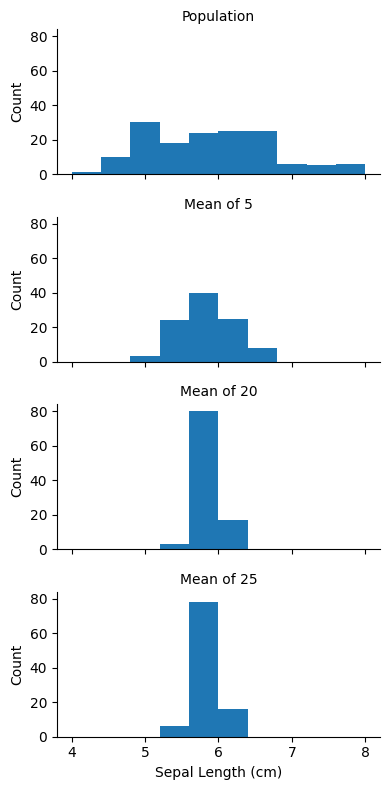

In [11]:
g = sns.FacetGrid(results, col='type', col_wrap=1, height=2, aspect=2)
g.map(plt.hist, 'sepal_length_mean', range=[4, 8], bins=10)
g.set_axis_labels('Sepal Length (cm)', 'Count')
g.set_titles('{col_name}')
plt.tight_layout()
plt.show()

# The Bootstrap

In [12]:
results = []
for nrepeat in range(1000):
    sample = resample(sepal_length)
    results.append(sample.median())
results = pd.Series(results)
print('Bootstrap Statistics:')
print(f'bias: {results.median() - sepal_length.median()}')
print(f'std. error: {results.std()}')

Bootstrap Statistics:
bias: 0.0
std. error: 0.10660047448844287


# Confidence Intervals

1. A 90% confidence interval gives a range of values that is likely to contain the true population mean, based on the sample.

2.If we repeatedly took samples and built 95% confidence intervals, about 95% of those intervals would contain the true population mean.

3.The confidence interval computed from the sample is likely to contain the true population mean.

5.843333333333334
5.66


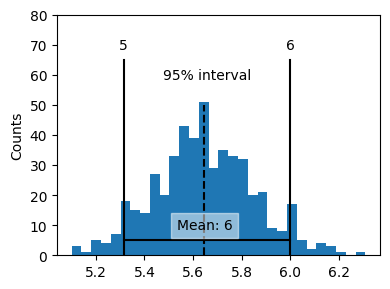

In [13]:
print(sepal_length.mean())
np.random.seed(seed=3)  
# create a sample of 20 sepal_lengthdata
sample20 = resample(sepal_length, n_samples=20, replace=False)
print(sample20.mean())
results = []
for nrepeat in range(500):
    sample = resample(sample20)
    results.append(sample.mean())
results = pd.Series(results)

confidence_interval = list(results.quantile([0.05, 0.95]))
ax = results.plot.hist(bins=30, figsize=(4, 3))
ax.plot(confidence_interval, [5, 5], color='black')
for x in confidence_interval:
    ax.plot([x, x], [0, 65], color='black')
    ax.text(x, 70, f'{x:.0f}', 
            horizontalalignment='center', verticalalignment='center')
ax.text(sum(confidence_interval) / 2, 60, '95% interval',
        horizontalalignment='center', verticalalignment='center')

meanSepal_length = results.mean()
ax.plot([meanSepal_length, meanSepal_length], [0, 50], color='black', linestyle='--')
ax.text(meanSepal_length, 10, f'Mean: {meanSepal_length:.0f}',
        bbox=dict(facecolor='white', edgecolor='white', alpha=0.5),
        horizontalalignment='center', verticalalignment='center')
ax.set_ylim(0, 80)
ax.set_ylabel('Counts')

plt.tight_layout()
plt.show()

The above figure shows a 95% confidence interval for the Sepal length of flowers, based on a sample of 20 for which the mean was 5.66.

# Normal Distribution
## Standard Normal and QQ-Plots
The package _scipy_ has the function (`scipy.stats.probplot`) to create QQ-plots. The argument `dist` specifies the distribution, which is set by default to the normal distribution.

1. Define a figure and axes
2. Generate random data from a normal distribution
stats.norm → a normal (Gaussian) distribution
rvs → random variates
size=100 → generate 100 random values
3. Create a probability (Q–Q) plot
stats.probplot() creates a Q–Q (quantile–quantile) plot
It compares observed data quantiles (your sample) with theoretical normal distribution quantiles
What the plot shows:
X-axis → theoretical quantiles (from a normal distribution)
Y-axis → sample quantiles (your data)
A reference straight line
If the data is normally distributed, the points should fall close to the line.

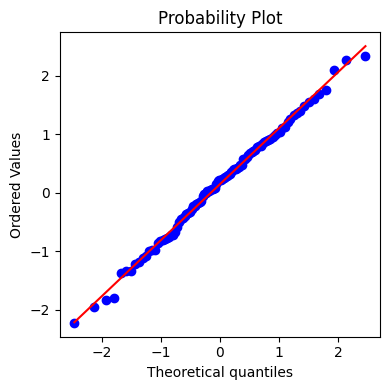

In [14]:
fig, ax = plt.subplots(figsize=(4, 4))
norm_sample = stats.norm.rvs(size=100)
stats.probplot(norm_sample, plot=ax)
plt.tight_layout()
plt.show()

The above figure shows a QQ-Plot for a sample of 100 values ran-domly generated from a normal distribution; as expected, the points closely follow the line. 

The following code explains the normal distibtuion for the iris dataset 

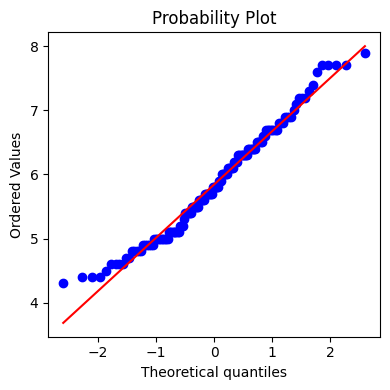

In [16]:
fig, ax = plt.subplots(figsize=(4, 4))
sample = df["sepal length (cm)"]
stats.probplot(sample, plot=ax)
plt.tight_layout()
plt.show()

# Long-Tailed Distributions

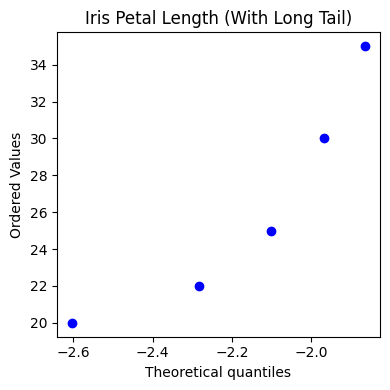

In [17]:
# Modified iris dataset to show long-tail distribution

iris_long_tail = df.copy()

# add 5 extreme values
large_values = np.array([20, 22, 25, 30, 35])
iris_long_tail.loc[:4, "petal_length"] = large_values
fig, ax = plt.subplots(figsize=(4, 4))
stats.probplot(iris_long_tail['petal_length'], plot=ax)
ax.set_title("Iris Petal Length (With Long Tail)")
plt.tight_layout()
plt.show()

When the data is extremely non-normal, the Q–Q reference line may become visually meaningless. The absence of a visible line is itself a signal of a heavy-tailed distribution.

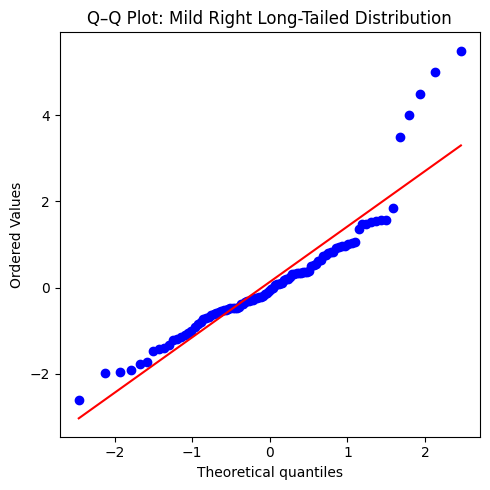

In [18]:
# This example shows the difference between normal and long-tail distribution
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# mostly normal data
normal_part = np.random.normal(loc=0, scale=1, size=95)

# mild right-tail values (not too extreme)
tail_part = np.array([3.5, 4.0, 4.5, 5.0, 5.5])

long_tail_sample = np.concatenate([normal_part, tail_part])
fig, ax = plt.subplots(figsize=(5, 5))
stats.probplot(long_tail_sample, plot=ax)
ax.set_title("Q–Q Plot: Mild Right Long-Tailed Distribution")

plt.tight_layout()
plt.show()

The figure shows a  clear straight line through most points, the points closely follow the line in the center and the right-most points curve upward 
Most of the data behaves normally, but a small number of unusually large values create a long right tail that breaks the normality assumption.

In [19]:
# Simulate a population with known σ
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(0)

mu = 50
sigma = 10
population = np.random.normal(mu, sigma, size=100000)

n = 10
z_scores = []

for _ in range(5000):
    sample = np.random.choice(population, size=n)
    xbar = sample.mean()
    
    # Standardize using TRUE sigma
    z = (xbar - mu) / (sigma / np.sqrt(n))
    z_scores.append(z)


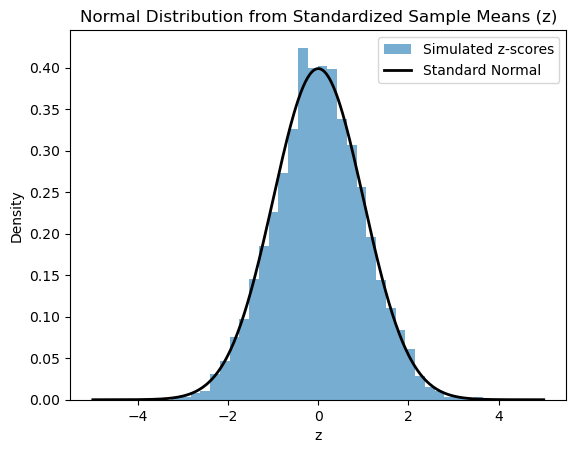

In [ ]:
x = np.linspace(-5, 5, 400)

plt.hist(z_scores, bins=40, density=True, alpha=0.6, label='Simulated z-scores')
plt.plot(x, norm.pdf(x), 'k', lw=2, label='Standard Normal')
plt.legend()
plt.title("Normal Distribution from Standardized Sample Means (z)")
plt.xlabel("z")
plt.ylabel("Density")
plt.show()

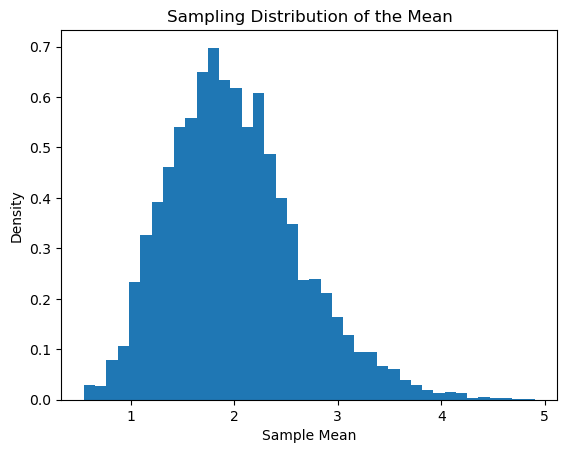

In [ ]:
# Plot z-scores
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

population = np.random.exponential(scale=2, size=100000)  # skewed pop
n = 10
means = []

for _ in range(5000):
    sample = np.random.choice(population, size=n)
    means.append(sample.mean())

plt.hist(means, bins=40, density=True)
plt.title("Sampling Distribution of the Mean")
plt.xlabel("Sample Mean")
plt.ylabel("Density")
plt.show()


In [21]:
from seaborn import load_dataset("mpg")

SyntaxError: invalid syntax (321751301.py, line 1)